In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

/Users/prakhar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


In [3]:
patch_size = 32
kernel_size = patch_size
image_size = 128
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 5
max_skew = 0

margin = 500
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 16
epochs = 100000
num_filters = 4
num_sin_waves = 8
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [4]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [5]:
def get_fixed_homography_matrix(val):
    rotation = rotation_multiple*val
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [6]:
def get_random_homography_matrix(whole_image =False):
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(top_right_to_centre if whole_image else patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), centre_to_top_right if whole_image else  patch_centre_to_top_right))
    return homography_matrix

In [7]:
def l2(p1,p2):
    dis=0
    for i in range(len(p1)):
        dis += (p1[i] - p2[i])**2
    
    return math.sqrt(dis)

In [8]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            
            # img = cv2.imread(os.path.join(image_dir_path, image))
            # img = cv2.resize(img, (image_size, image_size))
            # img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # img = img/255
            self.img_list.append(os.path.join(image_dir_path, image))
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        while len(original_images) < self.batchsize:
            kp = None
            while(kp is None):
                current_image_no = batch
                current_image_path = self.img_list[current_image_no]
                current_image = cv2.imread(current_image_path)
                current_image = cv2.resize(current_image, (image_size, image_size))
                current_image = cv2.cvtColor(current_image, cv2.COLOR_RGB2GRAY)
                current_image = current_image/255
                orb= cv2.ORB_create(100)
                kp = orb.detect((np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8))
                if len(kp) < 5:
                    kp = None
            k=0
            got =False
            while(not got):
                k=np.random.choice(kp)
                if(k.pt[0] >(patch_size/2) and k.pt[1] >(patch_size/2) and k.pt[1]<image_size-((patch_size/2) )and k.pt[0]<image_size-((patch_size/2))):
                    got = True
            x= k.pt[0]
            y= k.pt[1]
            
            
            current_patch = current_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            # current_patch = cv2.blur(current_patch, (3,3))
            #transform image 
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size , image_size))
            points_to_transform = np.array([[x, y]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
        
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            # test_original_image =(np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8)
            # test_transformed_image = (np.repeat(np.expand_dims(transformed_image,-1),3,-1)*255).astype(np.uint8)
            # cv2.circle(test_original_image,(int( k.pt[0]), int(k.pt[1])),3,(255,0,0))
            # cv2.circle(test_transformed_image,(int(transformed_points[0][0][0]), int(transformed_points[0][0][1])),3,(255,0,0))
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            # X = np.random.randint(0,image_size - patch_size)
            # Y = np.random.randint(0,image_size - patch_size)
            # random_image_no = np.random.randint(0, len(self.img_list))
            # random_image = self.img_list[random_image_no]
            # while(x==X & y==Y & random_image_no == current_image_no):
            #     X = np.random.randint(0,image_size - patch_size)
            #     Y = np.random.randint(0,image_size - patch_size)
            k_r=k
            got=False
            while(l2(k.pt,k_r.pt) < 10 or (not got)):
                k_r=np.random.choice(kp)
                if(k_r.pt[0] >(patch_size/2) and k_r.pt[1] >(patch_size/2) and k_r.pt[1]<image_size-((patch_size/2))and k_r.pt[0]<image_size-((patch_size/2))):
                    got=True
            
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size, image_size))
            points_to_transform = np.array([[k_r.pt[0], k_r.pt[1]]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)

            if not ((non_matches[-1].shape == matches[-1].shape) & (original_images[-1].shape == matches[-1].shape)):
                original_images.pop()
                matches.pop()
                non_matches.pop()
        
        original_images = np.array(original_images)
        matches = np.array(matches)
        non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

Test data generation


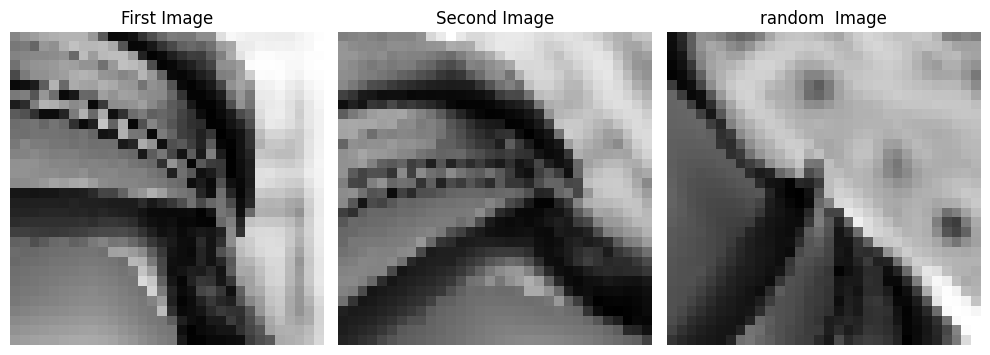

In [9]:
test_data_gen = CustomDataGenerator("real_images", batch_size)
print("Test data generation")
o,t,r = test_data_gen.__getitem__(0)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(o[0]*1,cmap='gray')
# axes[0].imshow(o[0]*255)
axes[0].set_title('First Image')
axes[0].axis('off')

# Plot the second image
axes[1].imshow(t[0]*1,cmap='gray')
# axes[1].imshow(t[0]*255)
axes[1].set_title('Second Image')
axes[1].axis('off')

axes[2].imshow(r[0]*1,cmap='gray')
# axes[1].imshow(t[0]*255)
axes[2].set_title('random  Image')
axes[2].axis('off')

# Display the plot
plt.tight_layout()
plt.show()

In [10]:
tan_inverse = np.zeros((patch_size, patch_size))
distances = np.zeros((patch_size, patch_size))
center_i, center_j = tan_inverse.shape[0]//2, tan_inverse.shape[1]//2
for i in range(tan_inverse.shape[0]):
    for j in range(tan_inverse.shape[1]):
        tan_inverse[i,j] = np.arctan2(i - center_i, j - center_j)
        distances[i,j] = np.sqrt((i - center_i)**2 + (j - center_j)**2)

In [11]:
Amplitudes = []
Freq = []
Phase = []
Radius = []
for i in range(num_filters):
    amp = []
    freq = []
    phase = []
    for j in range(num_sin_waves):
        amp.append( tf.Variable(np.random.uniform(0,1)))
        freq.append(tf.Variable(np.asarray(np.random.randint(8,10),np.float32)))
        phase.append(tf.Variable(np.random.normal()))
        
    Amplitudes.append(amp)
    Freq.append(freq)
    Phase.append(phase)
    Radius.append(tf.Variable((patch_size/2) * np.random.uniform(0, 1)))

In [12]:
def create_circle_sine_wave_image(Amp, Freq, Phase, Radius, tan_inverse, distances):
    values = np.zeros((len(Amplitudes), len(Amplitudes[0]), len(tan_inverse), len(tan_inverse[0])))
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Freq[i][j] * tan_inverse
            
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Phase[i][j] + values[i][j]
    print("=======")
    print(values)
    values[i, j] = tf.sin(values[i, j])
    print("=======")
    print(values)
    for i in range(len(Amp)):
        for j in range(len(Amp[0])):
            values[i, j] = Amp[i][j] * values[i][j]
    print("=======")
    print(values)
    for i in range(len(Radius)):
        values[i] = Radius[i] * values[i]
    print("=======")
    print(values)
    values = tf.reduce_sum(values, axis=1)
    print("=======")
    print(values)
    
    return values
    

In [13]:
def one_filter(amplitude,freq,phase,radius,tan_inverse,distances):
    res = tf.zeros_like(distances, dtype=tf.float32)
    for i in range(len(amplitude)):
        res=res+amplitude[i]* tf.sin(freq[i] *tan_inverse + phase[i])
    f=  2-tf.abs(distances - radius*(1+res))
    one=tf.ones(f.shape,dtype=tf.float32)
    zeros=tf.zeros(f.shape,dtype=tf.float32)
    # f=tf.where(f>0,one,zeros)
    return f

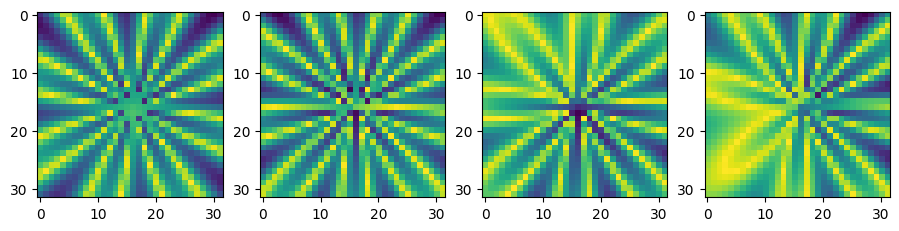

In [14]:
filters = []
fig, ax = plt.subplots(ncols=num_filters, figsize = (11,6))
zeros=tf.zeros(tan_inverse.shape,dtype=tf.float32)
for i in range(num_filters):
    filters.append(one_filter(Amplitudes[i], Freq[i], Phase[i], Radius[i], tan_inverse, distances))
    ax[i].imshow(filters[i])

In [15]:
def get_decriptors(images, filters, intensities):
    descriptors = []
    for i,image in enumerate(images):
        current_decriptor = []
        for filter_image in filters:
            activations = tf.multiply(image[:,:,0]  ,filter_image)
            
            # activations = tf.where(activations>intensities[i],tf.ones_like(activations),tf.zeros_like(activations))
            count = tf.reduce_mean(activations)
            current_decriptor.append(count)
        descriptors.append(current_decriptor)
    return descriptors

def get_L2_dist(l1, l2):
    loss = 0
    for i in range(len(l1)):
        sum = 0
        for j in range(len(l1[0])):
            sum += tf.square(l1[i][j] - l2[i][j])
        loss += sum
    # loss /= len(l1)
    return loss

In [16]:
Amplitudes= tf.Variable(tf.random.uniform((num_filters,num_sin_waves)),dtype=tf.float32)
Freq= tf.Variable(tf.random.uniform((num_filters,num_sin_waves),6,20),dtype=tf.float32)
Phase= tf.Variable(tf.random.uniform((num_filters,num_sin_waves),0,500),dtype=tf.float32)
Radius= tf.Variable(tf.random.uniform((num_filters,),0,int(patch_size *0.8)))


print(Amplitudes[0])

print(f"the shapes are Amplitude = {Amplitudes.shape} and Phase = {Phase.shape} and Freq = {Freq.shape} and Radius = {Radius.shape}")


tf.Tensor(
[0.69691527 0.7555386  0.39819205 0.7575686  0.6355405  0.15908265
 0.53451896 0.26116896], shape=(8,), dtype=float32)
the shapes are Amplitude = (4, 8) and Phase = (4, 8) and Freq = (4, 8) and Radius = (4,)


In [17]:
def clipping (arr):
    # return 20*(tf.clip_by_value(arr,clip_value_min=0.0,clip_value_max=1/20))
    return tf.sigmoid(arr *50)
    # return arr


In [19]:
def train():
    avg_loss =0
    for i in range(epochs):
        original_images, matches, non_matches = test_data_gen.__getitem__(0)
        original_centers = original_images[:, original_images.shape[1]//2, original_images.shape[2]//2, :]
        matches_centers = matches[:, original_images.shape[1]//2, original_images.shape[2]//2, :]
        non_matches_centers = non_matches[:, original_images.shape[1]//2, original_images.shape[2]//2, :]
        for j in range(original_images.shape[0]):
            original_images[j] = original_images[j] - original_centers[j]
            matches[j] = matches[j] - matches_centers[j]
            non_matches[j] = non_matches[j] - non_matches_centers[j]
            
        original_images = np.repeat(np.expand_dims(np.reshape(original_images,(batch_size,patch_size,patch_size)),1),num_filters,1)
        matches = np.repeat(np.expand_dims(np.reshape(matches,(batch_size,patch_size,patch_size)),1),num_filters,1)
        non_matches = np.repeat(np.expand_dims(np.reshape(non_matches,(batch_size,patch_size,patch_size)),1),num_filters,1)
        # print(original_images.shape)
        angles  = tf.cast(tf.tile(tf.expand_dims(tf.expand_dims(tan_inverse,0),0),(num_filters,num_sin_waves,1,1)),dtype=tf.float32)
        # print('tan_inverse shape' , angles.shape)
        dist = tf.cast(tf.repeat(tf.expand_dims(distances,0),num_filters,0),dtype=tf.float32)
        # print('dist shape' , dist.shape)
        
        
        # zeros=tf.zeros(tan_inverse.shape,dtype=tf.float32)
        with tf.GradientTape() as tape:
            freq =tf.tile(tf.expand_dims(tf.expand_dims(Freq,-1),-1),(1,1,patch_size,patch_size))
            phase =tf.tile(tf.expand_dims(tf.expand_dims(Phase,-1),-1),(1,1,patch_size,patch_size))
            amplitudes =tf.tile(tf.expand_dims(tf.expand_dims(Amplitudes,-1),-1),(1,1,patch_size,patch_size))
            radius  = tf.tile(tf.expand_dims(tf.expand_dims(Radius,-1),-1),(1,patch_size,patch_size))           
            filters = tf.multiply(radius,(tf.reduce_sum(tf.multiply(tf.sin(tf.multiply(freq,angles) +phase),amplitudes),axis=1)+1.0))

            final_dist = 2.3-tf.abs(dist - filters)
            
            final_dist=final_dist
            final_filter=clipping(final_dist)
            batch_filter=tf.repeat(tf.expand_dims(final_filter,0),batch_size,0)
            # print('final_filter shape',final_filter.shape)
            # print('batch_filter shape',batch_filter.shape)
            # print('orignal  shape',original_images.shape)
            # plt.imshow(final_filter[0],cmap='gray')
            # break
            batch_orignal_activated  =clipping(tf.multiply(batch_filter,original_images))
            batch_matches_activated  =clipping(tf.multiply(batch_filter,matches))
            batch_non_matches_activated =clipping(tf.multiply(batch_filter,non_matches))
            des_original=tf.reduce_sum(batch_orignal_activated,axis=(2,3))
            des_matches=tf.reduce_sum(batch_matches_activated,axis=(2,3))
            des_non_matches=tf.reduce_sum(batch_non_matches_activated,axis=(2,3))
            # des=tf.reduce_mean(final_dist,axis=(1,2))
            # print('descriptor shape',des_original.shape)
            # print( 'near',tf.reduce_mean(tf.square(des_original-des_matches)))
            # print('far',tf.reduce_mean(tf.square(des_original-des_non_matches)))
            loss = tf.maximum(0.0, tf.reduce_mean(tf.square(des_original-des_matches)) - tf.reduce_mean(tf.square(des_original-des_non_matches)) + 1500)
            avg_loss = avg_loss + loss
            gradients = tape.gradient(loss, [Amplitudes,Freq,Phase,Radius])  
            if(i%100 == 99):
                print('avg_loss ',avg_loss/100)
                avg_loss = 0
                filters_numpy = final_filter.numpy()
                np.save('saved_model/filters_numpy.npy', filters_numpy)
                for k in range(filters_numpy.shape[0]):
                    cv2.imwrite(f'filters/filter_{k}.png', filters_numpy[k]*255)
                    
                    # plt.imshow(filters_numpy[k], cmap='gray')
                    # plt.show()
                
            # if(i%500 == 0):      
            #     print('gradients ',gradients)
            # Update weights
            optimizer.apply_gradients(zip(gradients, [Amplitudes,Freq,Phase,Radius]))
            
    
train()

avg_loss  tf.Tensor(116.0678, shape=(), dtype=float32)
avg_loss  tf.Tensor(104.92203, shape=(), dtype=float32)
avg_loss  tf.Tensor(88.20395, shape=(), dtype=float32)
avg_loss  tf.Tensor(87.42823, shape=(), dtype=float32)
avg_loss  tf.Tensor(78.26752, shape=(), dtype=float32)


In [ ]:
angles  = tf.cast(tf.tile(tf.expand_dims(tf.expand_dims(tan_inverse,0),0),(num_filters,num_sin_waves,1,1)),dtype=tf.float32)
# print('tan_inverse shape' , angles.shape)
dist = tf.cast(tf.repeat(tf.expand_dims(distances,0),num_filters,0),dtype=tf.float32)
# print('dist shape' , dist.shape)
freq =tf.tile(tf.expand_dims(tf.expand_dims(Freq,-1),-1),(1,1,patch_size,patch_size))
phase =tf.tile(tf.expand_dims(tf.expand_dims(Phase,-1),-1),(1,1,patch_size,patch_size))
amplitudes =tf.tile(tf.expand_dims(tf.expand_dims(Amplitudes,-1),-1),(1,1,patch_size,patch_size))
radius  = tf.tile(tf.expand_dims(tf.expand_dims(Radius,-1),-1),(1,patch_size,patch_size))
                    
filters = tf.multiply(radius,(tf.reduce_sum(tf.multiply(tf.sin(tf.multiply(freq,angles) +phase),amplitudes),axis=1)+1.0))

final_dist = 2.3-tf.abs(dist - filters)

final_dist=final_dist
final_filter=clipping(final_dist)

(8, 128, 128)


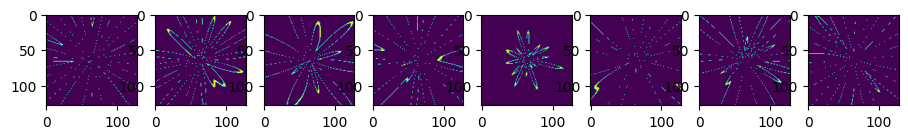

In [ ]:
Filters = final_filter.numpy()
fig, ax = plt.subplots(ncols=num_filters, figsize = (11,6))
zeros=tf.zeros(tan_inverse.shape,dtype=tf.float32)
print(Filters.shape)
for i in range(num_filters):
    ax[i].imshow(Filters[i])